# **Imports**

In [28]:

from earthscape.utils.constants import VERSION, ASSETS_DIR
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# **Setup**

In [31]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/classification/baselines'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modalities...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")


col_mapper = {
        'Precision (Macro)': 'precision', 
        'Recall (Macro)': 'recall', 
        'F1 (Macro)': 'f1', 
        'AUC (Macro)': 'auroc', 
        'mAP (Macro)': 'map', 
        'Accuracy (Micro)': 'accuracy'
        }


sorted_cols = [
    'model', 'input', 
    'precision (id)', 'precision (cd)', 
    'recall (id)', 'recall (cd)', 
    'f1 (id)', 'f1 (cd)', 
    'map (id)', 'map (cd)', 
    'auroc (id)', 'auroc (cd)', 
    'accuracy (id)', 'accuracy (cd)'
    ]


# output directory for visualizations...
assets_dir = os.path.join(ASSETS_DIR, 'baselines')
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)

# **Performance Metrics Compilation**

## *Single Modality Experiments*

In [32]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'single_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_global = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    meta = meta[:-2]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.rename(columns=col_mapper, inplace=True)
    id = id[col_mapper.values()]
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.rename(columns=col_mapper, inplace=True)
    cd = cd[col_mapper.values()]
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_global.loc[idx, 'model'] = meta[0]
    df_global.loc[idx, 'input'] = '+'.join(meta[1:])
    df_global.loc[idx, id.columns] = id.values
    df_global.loc[idx, cd.columns] = cd.values
    
# rename & sort columns...
df_global = df_global[sorted_cols]

# calculate deltas of in-domain vs. cross-domain F1 and mAP...
df_global.insert(loc=8, column='f1 (delta)', value=df_global['f1 (id)'] - df_global['f1 (cd)'])
df_global.insert(loc=11, column='map (delta)', value=df_global['map (id)'] - df_global['map (cd)'])

# save & display...
df_global.to_csv(output_path, index=False)
df_global.sort_values('f1 (id)', ascending=False).head(10)

,model,input,precision (id),precision (cd),recall (id),recall (cd),f1 (id),f1 (cd),f1 (delta),map (id),map (cd),map (delta),auroc (id),auroc (cd),accuracy (id),accuracy (cd)
1,resnet18,dem,0.632032,0.433786,0.757646,0.636282,0.674445,0.498615,0.175830,0.723064,0.561486,0.161579,0.900300,0.754346,0.869978,0.804967
79,swin,ep51,0.641919,0.518780,0.710842,0.464584,0.672642,0.472658,0.199984,0.709659,0.514044,0.195615,0.885860,0.770872,0.866815,0.837240
6,resnet18,ep51,0.650318,0.516121,0.678511,0.438448,0.662626,0.458288,0.204339,0.706028,0.501826,0.204202,0.879048,0.738620,0.868397,0.832868
29,resnet18,s5,0.641725,0.513334,0.676919,0.693743,0.657348,0.583447,0.073901,0.702212,0.604618,0.097594,0.865970,0.834408,0.872024,0.843657
25,resnet18,s10,0.605704,0.493866,0.722063,0.683004,0.648167,0.566534,0.081633,0.676622,0.576584,0.100039,0.872491,0.822298,0.861235,0.837426
41,resnet50,ep21,0.649682,0.463316,0.658071,0.393030,0.647674,0.414114,0.233561,0.699904,0.470928,0.228977,0.866821,0.703898,0.866536,0.827567
102,swin,s5,0.593912,0.508533,0.727014,0.719425,0.646117,0.589164,0.056953,0.683052,0.592853,0.090198,0.871462,0.797920,0.854725,0.837054
5,resnet18,ep21,0.699098,0.458631,0.657667,0.368359,0.645745,0.373070,0.272675,0.694192,0.431821,0.262371,0.876226,0.653095,0.865885,0.825242
4,resnet18,ep201,0.591664,0.480999,0.737600,0.585677,0.645589,0.522795,0.122793,0.700262,0.550180,0.150082,0.879502,0.809616,0.853888,0.830078
18,resnet18,prc10,0.635576,0.505168,0.661551,0.641485,0.645553,0.560533,0.085020,0.686156,0.587544,0.098612,0.872033,0.794200,0.871466,0.853795


## *Multi-scale Experiments*

In [33]:
##################################################
# Compile Global Performance Metrics - Multi-scale
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multiscale_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_global = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    meta = meta[:-2]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.rename(columns=col_mapper, inplace=True)
    id = id[col_mapper.values()]
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.rename(columns=col_mapper, inplace=True)
    cd = cd[col_mapper.values()]
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_global.loc[idx, 'model'] = meta[0]
    df_global.loc[idx, 'input'] = '+'.join(meta[1:])
    df_global.loc[idx, id.columns] = id.values
    df_global.loc[idx, cd.columns] = cd.values
    
# rename & sort columns...
df_global = df_global[sorted_cols]
df_global['input'] = df_global['input'] + '-ms'

# calculate deltas of in-domain vs. cross-domain F1 and mAP...
df_global.insert(loc=8, column='f1 (delta)', value=df_global['f1 (id)'] - df_global['f1 (cd)'])
df_global.insert(loc=11, column='map (delta)', value=df_global['map (id)'] - df_global['map (cd)'])

# save & display...
df_global.to_csv(output_path, index=False)
df_global.sort_values('f1 (id)', ascending=False).head(10)

,model,input,precision (id),precision (cd),recall (id),recall (cd),f1 (id),f1 (cd),f1 (delta),map (id),map (cd),map (delta),auroc (id),auroc (cd),accuracy (id),accuracy (cd)
13,swin,prc-ms,0.621317,0.509755,0.758333,0.653053,0.666651,0.568276,0.098375,0.711312,0.612352,0.098960,0.902279,0.790495,0.870257,0.854260
1,resnet18,ep-ms,0.648728,0.581791,0.696411,0.510169,0.665439,0.537261,0.128178,0.711623,0.588564,0.123059,0.901517,0.811661,0.880487,0.864583
3,resnet18,prc-ms,0.652260,0.551429,0.702655,0.683124,0.665276,0.607321,0.057955,0.722335,0.628068,0.094267,0.904828,0.797365,0.884766,0.866815
8,resnet50,prc-ms,0.617859,0.506313,0.734553,0.661350,0.662551,0.569305,0.093247,0.709917,0.610093,0.099825,0.896834,0.769559,0.867653,0.853051
5,resnet18,s-ms,0.622760,0.536722,0.743984,0.666760,0.661589,0.590085,0.071504,0.703226,0.609743,0.093484,0.884560,0.836695,0.867653,0.855097
11,swin,ep-ms,0.619849,0.514465,0.717019,0.680077,0.658744,0.580942,0.077802,0.717919,0.607358,0.110561,0.892763,0.840597,0.870908,0.850632
15,swin,s-ms,0.634681,0.515951,0.684073,0.657182,0.651211,0.565850,0.085361,0.714217,0.592164,0.122053,0.893191,0.820588,0.877325,0.860491
2,resnet18,plc-ms,0.608981,0.466625,0.703020,0.692652,0.648811,0.549750,0.099061,0.678712,0.567221,0.111491,0.877220,0.804824,0.851656,0.803757
7,resnet50,plc-ms,0.608421,0.483369,0.727171,0.683674,0.648419,0.551320,0.097099,0.691622,0.568148,0.123474,0.873426,0.796056,0.850260,0.799200
10,resnet50,s-ms,0.627887,0.573911,0.685606,0.656286,0.646238,0.598594,0.047643,0.700947,0.635999,0.064948,0.884881,0.840203,0.871187,0.866722


## *Multimodal Experiments*

In [ ]:
##################################################


## *Compilation*

In [35]:
##################################################
# Compile All Global Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_global.csv")
ms_path = os.path.join(assets_dir, "multiscale_global.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_global.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))

df_global = pd.concat(df_list)
df_global.reset_index(drop=True, inplace=True)

df_global.to_csv(output_path, index=False)
df_global.sort_values('f1 (id)', ascending=False).head(10)

,model,input,precision (id),precision (cd),recall (id),recall (cd),f1 (id),f1 (cd),f1 (delta),map (id),map (cd),map (delta),auroc (id),auroc (cd),accuracy (id),accuracy (cd)
1,resnet18,dem,0.632032,0.433786,0.757646,0.636282,0.674445,0.498615,0.175830,0.723064,0.561486,0.161579,0.900300,0.754346,0.869978,0.804967
78,swin,ep51,0.641919,0.518780,0.710842,0.464584,0.672642,0.472658,0.199984,0.709659,0.514044,0.195615,0.885860,0.770872,0.866815,0.837240
156,swin,prc-ms,0.621317,0.509755,0.758333,0.653053,0.666651,0.568276,0.098375,0.711312,0.612352,0.098960,0.902279,0.790495,0.870257,0.854260
144,resnet18,ep-ms,0.648728,0.581791,0.696411,0.510169,0.665439,0.537261,0.128178,0.711623,0.588564,0.123059,0.901517,0.811661,0.880487,0.864583
146,resnet18,prc-ms,0.652260,0.551429,0.702655,0.683124,0.665276,0.607321,0.057955,0.722335,0.628068,0.094267,0.904828,0.797365,0.884766,0.866815
6,resnet18,ep51,0.650318,0.516121,0.678511,0.438448,0.662626,0.458288,0.204339,0.706028,0.501826,0.204202,0.879048,0.738620,0.868397,0.832868
151,resnet50,prc-ms,0.617859,0.506313,0.734553,0.661350,0.662551,0.569305,0.093247,0.709917,0.610093,0.099825,0.896834,0.769559,0.867653,0.853051
148,resnet18,s-ms,0.622760,0.536722,0.743984,0.666760,0.661589,0.590085,0.071504,0.703226,0.609743,0.093484,0.884560,0.836695,0.867653,0.855097
154,swin,ep-ms,0.619849,0.514465,0.717019,0.680077,0.658744,0.580942,0.077802,0.717919,0.607358,0.110561,0.892763,0.840597,0.870908,0.850632
29,resnet18,s5,0.641725,0.513334,0.676919,0.693743,0.657348,0.583447,0.073901,0.702212,0.604618,0.097594,0.865970,0.834408,0.872024,0.843657


# **Experiment Visualizations**

## *Modality Rankings*

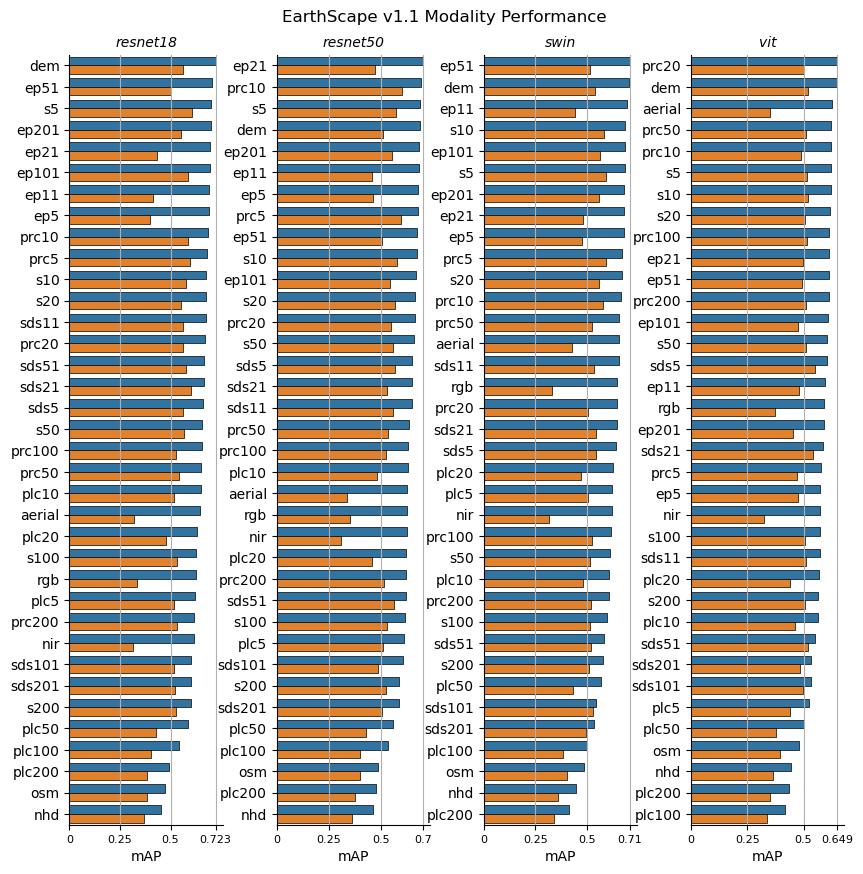

In [84]:
#############################################
# Modality Ranking Bar Charts
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'single_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# models to use...
models = ['resnet18', 'resnet50', 'swin', 'vit']

# output path for figure
output_path = os.path.join(assets_dir, 'modality_rankings.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(2.5*len(models),10))
plt.subplots_adjust(wspace=0.35)
ax = ax.ravel()

idx = 0
for m in df_single['model'].unique():

    if m in [model.lower() for model in models]:

        df = df_single[df_single['model'] == m].copy()
        df.sort_values(f"{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"{metric} (id)", f"{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}")
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Modality Performance", y=0.925)

plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

In [ ]:
import re


def support_bin(support_ft, custom_bins=[5, 10, 25, 50, 100, 250, 500, 1000]):
    if pd.isna(support_ft):
        return 'MS'
    
    # choose nearest canonical support family
    canonical = np.array(custom_bins)
    nearest = canonical[np.argmin(np.abs(canonical - support_ft))]
    return f"{int(nearest)} ft"


def parse_feature(feat, native_gsd=5):
    if feat.endswith('-ms'):
        family = feat.split('-')[0]
        return family, None, np.nan, 'MS'
    
    m = re.match(r'([a-zA-Z]+)(\d+)', feat)
    if not m:
        return None, None, np.nan, None
    
    family = m.group(1)
    raw = int(m.group(2))

    # DEM-resolution families: suffix is GSD in ft/pixel
    if family in ['s', 'prc', 'plc']:
        support_ft = raw * native_gsd
    
    # window-based families: suffix is window width in pixels on 5-ft DEM
    elif family in ['ep', 'sds']:
        support_ft = raw * native_gsd   # e.g. ep201 -> 1005 ft
    
    else:
        support_ft = np.nan

    return family, raw, support_ft, support_bin(support_ft)

In [39]:
import math

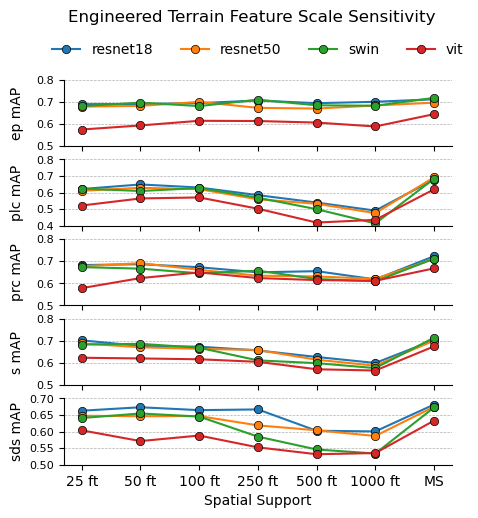

In [48]:
#############################################
# Terrain Feature Scale-Sensitivity
#############################################

# path to compiled data...
global_path = os.path.join(assets_dir, 'compiled_global.csv')
df_global = pd.read_csv(global_path)

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity.png')




##### pre-processing...
df_global[['family', 'raw_scale', 'support_ft', 'support_family']] = df_global['input'].apply(lambda x: pd.Series(parse_feature(x)))
support_order = ['25 ft', '50 ft', '100 ft', '250 ft', '500 ft', '1000 ft', 'MS']
df_global['support_family'] = pd.Categorical(df_global['support_family'], categories=support_order, ordered=True)



##### plot scale-sensitivity lines...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

families = ['ep', 'plc', 'prc', 's', 'sds']
plot_df = df_global[df_global['family'].isin(families)].copy()
for idx, fam in enumerate(families):
    fam_df = plot_df[plot_df['family'] == fam].copy()
    fam_df = fam_df.sort_values('support_family')

    models = plot_df['model'].dropna().unique()
    for m in models:
        model_df = fam_df[fam_df['model'] == m].copy()
        model_df = model_df.sort_values('support_family')

        ax[idx].plot(model_df['support_family'],model_df[f'{metric} (id)'], marker='o', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5, label=m)

    ax[idx].set_ylabel(f"{fam} {metric_label}")
    ax[idx].grid(True, axis='y', linestyle='--', linewidth=0.5)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)


ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)

for axes in ax:
    axes.set_xlabel('Spatial Support')
    axes.set_yticks(axes.get_yticks())
    axes.set_yticklabels(axes.get_yticklabels(), fontsize=8)

for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')

fig.align_ylabels()

plt.suptitle('Engineered Terrain Feature Scale Sensitivity', y=1.02)

plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

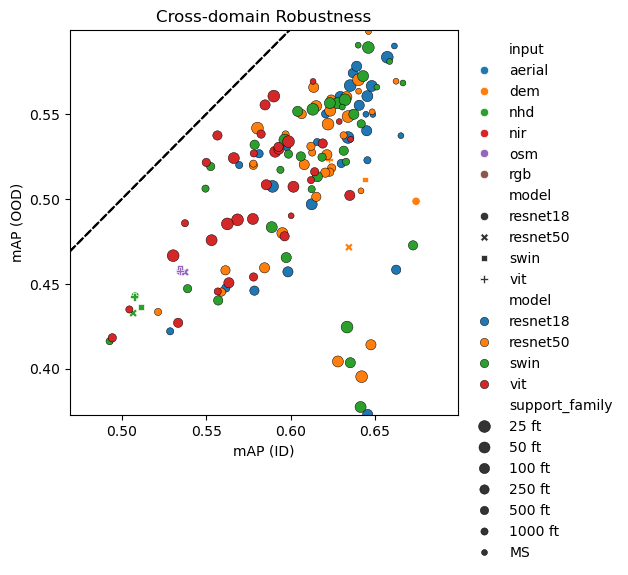

In [66]:
#############################################
# Cross-domain Performance
#############################################

mask = df_global['input'].isin(['dem', 'rgb', 'aerial', 'nir', 'osm', 'nhd'])
df_raw = df_global[mask]
df_eng = df_global[~mask]



fig, ax = plt.subplots(figsize=(5,5))


sns.scatterplot(df_raw, x='f1 (id)', y='f1 (cd)', hue='input', style='model', ax=ax)

sns.scatterplot(df_eng, x='f1 (id)', y='f1 (cd)', hue='model', size='support_family', size_order=support_order, edgecolor='k', ax=ax)


xmin = df[f"{metric} (id)"].min() + 0.05
xmax = df[f"{metric} (id)"].max() + 0.05
ymin = df[f"{metric} (cd)"].min() + 0.05
ymax = df[f"{metric} (cd)"].max() + 0.05
# lims = [np.min([ax.get_xlim(), ax.get_ylim()]),  np.max([ax.get_xlim(), ax.get_ylim()])]
lims = [(xmin, ymin),  (xmax, ymax)]
ax.plot(lims, lims, 'k', linestyle='--', zorder=0)
# ax.set_aspect('equal')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


ax.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)

ax.set_title('Cross-domain Robustness')
ax.set_xlabel(f"{metric_label} (ID)")
ax.set_ylabel(f"{metric_label} (OOD)")

plt.show()

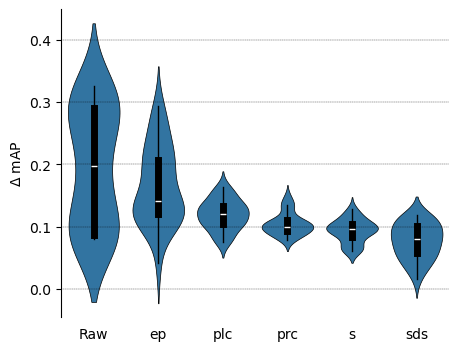

In [151]:


# df2 = pd.merge(left=df_single, right=df_mmd, how='left', left_on='input', right_on='Feature')

# df2 = df2[df2['model'] == 'resnet50']

# df2[['family', 'raw_scale', 'support_ft', 'support_family']] = df2['input'].apply(lambda x: pd.Series(parse_feature(x)))

df_global['family'] = df_global['family'].fillna(value='Raw')



fig, ax = plt.subplots(figsize=(5,4))

inner_kws={'box_width':5, 'whis_width': 1, 'color':'k'}
sns.violinplot(data=df_global, y='map (delta)', x='family', linewidth=0.5, linecolor='k', density_norm='width', inner_kws=inner_kws)

# ax.legend(loc='upper right', bbox_to_anchor=(1,1), frameon=False, ncols=3)

# ax.set_xticks(None)
ax.set_xlabel('')
ax.set_ylabel(r'$\Delta$ mAP')
ax.tick_params(bottom=False)
ax.grid(visible=True, axis='y', linestyle='--', linewidth=0.25, color='k')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.show()


## *per-Class Performance*

### Summary Table

### Visualizations